# Обработчик осциллограмм

#### Установка всех необходимых библиотек (если какие-то отсутствуют)

In [ ]:
!pip install pandas matplotlib openpyxl watchdog

#### Создание файла с параметрами образца

In [ ]:
import pandas as pd
import os 
from openpyxl.styles import Font
from openpyxl import load_workbook
from datetime import datetime

sample = '450.3'
file_name = 'parameters/' + sample + '.xlsx'
today = datetime.now().strftime("%d.%m.%Y")

df1 = pd.DataFrame(columns=['Shot',	'Ток накачки усилителя, А',	'Энергия, нДж',	
                           'Количество', 'Общая энергия, нДж', 'Спектр ЗГ', 
                           'Спектр ЗГ с усилением'])

df2 = pd.DataFrame(columns=['Ток накачки усилителя, А',	'Выходная мощность после усилителя со скважностью ½, мВт',	
                            'Энергия одного импульса, нДж',	'Расчетная энергия, нДж'])


# Проверяем, существует ли файл
if os.path.exists(file_name):
    # Если файл существует, загружаем его
    with pd.ExcelWriter(file_name, engine='openpyxl', mode='a') as writer:
        # Проверяем, существуют ли листы с текущей датой
        book = load_workbook(file_name)
        if today not in book.sheetnames:
            df1.to_excel(writer, index=False, sheet_name=today)
        if f'{today} energy' not in book.sheetnames:
            df2.to_excel(writer, index=False, sheet_name=f'{today} energy')
    print("Новые листы успешно добавлены!")
else:
    # Если файла нет, создаем новый
    with pd.ExcelWriter(file_name, engine='openpyxl') as writer:
        df1.to_excel(writer, index=False, sheet_name=today)
        df2.to_excel(writer, index=False, sheet_name=f'{today} energy')
    print("Excel-файл успешно создан!")

# Загружаем книгу
book = load_workbook(file_name)

# Для каждого листа
for sheet_name in book.sheetnames:
    ws = book[sheet_name]

    # Настраиваем ширину столбцов
    for col in ws.columns:
        max_length = 0
        column = col[0].column_letter  # Получаем букву столбца
        for cell in col:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = (max_length + 2) * 1.2  # Добавляем немного отступов
        ws.column_dimensions[column].width = adjusted_width

    # Настраиваем шрифт заголовков
    header_font = Font(name='Calibri', size=12, bold=False)  # Убираем жирный шрифт
    for cell in ws[1]:  # Первая строка содержит заголовки
        cell.font = header_font

# Сохраняем изменения
book.save(file_name)

Новые листы успешно добавлены!


#### Сама программа

0     7.441860
1    11.162791
2    14.883721
3    18.604651
4    22.325581
Name: Энергия одного импульса, нДж, dtype: float64
Energy is calculated and stored
450.3_1_1_11.16
1.csv


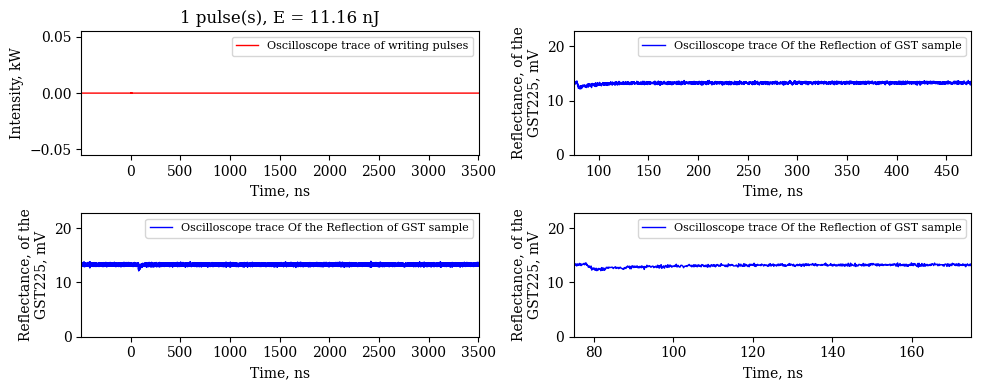

KeyboardInterrupt: Interrupted by user

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os 
import numpy as np
import time
import logging
import win32com.client as win32
import pythoncom

from watchdog.observers import Observer
from watchdog.events import FileSystemEventHandler
from openpyxl import load_workbook
from openpyxl.utils.dataframe import dataframe_to_rows
from datetime import datetime


# ПАРАМЕТРЫ
sample = '450.2'    # маркер образца
today = datetime.now().strftime("%d.%m.%Y")

start_file = None   # Если в папке с осциллограммами уже есть файлы и нужно обработать не все, 
                    # УКАЗАТЬ название файла, с кого начать (перед ним все проспускаются)

dir = 'osc/'     # папка с осциллограммами

save_dir = 'results/' + sample + '/'    # папка для результатов каждого из образцов
general_file = 'parameters/' + sample + '.xlsx'   # файл с параметрами образцов



############################################################ Тут все функции
def create_dir():
    try:
        os.makedirs(save_dir)
    except FileExistsError:
        # directory already exists
        pass


def plot_graph(df, x, y, color_, label_, ylabel, xlabel, xlim1, xlim2):
    plt.xlim(xlim1, xlim2)
    plt.ylabel(ylabel, fontsize=10)
    plt.xlabel(xlabel, fontsize=10)
    plt.plot(df[x]*1e9, df[y]*1e3, color=color_, linewidth=1,
             label=label_)
    plt.legend(fontsize=8)


def plot_graphics(df, pulses, energy, flag_pulse, peak, y_start, y_end, y_avg, y_max, time_width):
    plt.figure(figsize=(10, 4))
    plt.rcParams["font.family"] = "serif" # font

    # 1) Без увеличения
    plt.subplot(2, 2, 1)
    plot_graph(df, x='TIME', y='CH1, kW', color_='red', 
        label_='Oscilloscope trace of writing pulses', 
        ylabel='Intensity, kW', xlabel='Time, ns', 
        xlim1=df.iloc[0, 0]*1e9, xlim2=df.iloc[-1, 0]*1e9)
    plt.title(label= f'{pulses} pulse(s), E = {energy} nJ')


    plt.subplot(2, 2, 3)
    plot_graph(df, x='TIME', y='CH2, V', color_='blue', 
        label_='Oscilloscope trace Of the Reflection of GST sample', 
        ylabel=r'Reflectance, of the' + '\n' +'GST225, mV', xlabel='Time, ns', 
        xlim1=df.iloc[0, 0]*1e9, xlim2=df.iloc[-1, 0]*1e9)
    plt.ylim(0, (y_max + y_avg*2/3 )*1e3)
    

    # 2) Увеличение
    plt.subplot(2, 2, 2)
    if (flag_pulse=='one'):
        plot_graph(df, x='TIME', y='CH2, V', color_='blue', 
            label_='Oscilloscope trace Of the Reflection of GST sample', 
            ylabel=r'Reflectance, of the' + '\n' +'GST225, mV', xlabel='Time, ns', 
            xlim1=75, xlim2=75 + time_width/10)
        plt.ylim(0, (y_max + y_avg*2/3 )*1e3)
        
    else:
        plot_graph(df, x='TIME', y='CH1, kW', color_='red', 
            label_='Oscilloscope trace of writing pulses', 
            ylabel='Intensity, kW', xlabel='Time, ns', 
            xlim1=df.iloc[0, 0]*1e9, xlim2=df.iloc[peak, 0]*1e9+926)


    # 3) Увеливение
    plt.subplot(2, 2, 4)
    if (flag_pulse=='one'):
        increase_ = 40
        xlim1_ = 75
        xlim2_ = xlim1_ + time_width/increase_
        
    else:
        xlim1_ = df.iloc[0, 0]*1e9
        xlim2_ = df.iloc[peak, 0]*1e9+926

    plot_graph(df, x='TIME', y='CH2, V', color_='blue', 
        label_='Oscilloscope trace Of the Reflection of GST sample', 
        ylabel=r'Reflectance, of the' + '\n' +'GST225, mV', xlabel='Time, ns', 
        xlim1=xlim1_, xlim2=xlim2_)
    plt.ylim(0, (y_max + y_avg*2/3 )*1e3)


    plt.tight_layout()  # Автоматическая регулировка расстояния между графиками
    

# Узнаем номер снимка
def osc_number(file):
    if ('Tek' in file):
        exp_number = file.replace('Tek', '')
        exp_number = exp_number.replace('.csv', '')
        exp_number = exp_number.replace('_ALL', '')
    else:
        exp_number = file.replace('shot', '')
        exp_number = exp_number.replace('.csv', '')

    return int(exp_number)


def last_peak(df, pulses):
    time = 926 *1e-9 * (pulses - 1)
    idx_nearest_time =  (df['TIME'] - time).abs().idxmin()
    return idx_nearest_time

def check_inf(df):
    # Найти индексы строк, где в столбце 'CH2, V' значения Inf
    inf_indexes = np.where(np.isinf(df['CH2, V']))[0]
    inf_indexes = inf_indexes[::-1]

    # Если есть строки с Inf
    if inf_indexes.size > 0:
        # Заменяем значения в 'CH1, V' и 'CH2, V' для всех строк с Inf на значения следующей строки
        for index in inf_indexes:
            if index < len(df) - 1:  # Проверяем, чтобы не выйти за пределы
                df.loc[index, 'CH2, V'] = df.loc[index + 1, 'CH2, V']

def file_name(num, pulses, energy):
    name = sample + '_' + str(num) + '_' + str(pulses) + '_' + str(energy)
    return name

def save_files(save_name, df):
    plt.savefig(save_dir + save_name + '.png', dpi=300, bbox_inches='tight')
    print(f"File {save_name + '.png'} is saved in {save_dir}")
    df.to_csv(save_dir + save_name + '.csv', index=False)
    print(f"File {save_name + '.csv'} is saved\n\n")

def save_column(file, df, sheet_):
    # Открываем Excel-файл
    book = load_workbook(file)
    sheet = book[sheet_]

    # # Записываем данные поверх существующих, без изменения формата
    for r_idx, row in enumerate(dataframe_to_rows(df, index=False, header=False), start=2):
        for c_idx, value in enumerate(row, start=1):
            sheet.cell(row=r_idx, column=c_idx, value=value)

    # # Сохраняем файл
    book.save(general_file)
        
def update_excel(file, sheet_name, data, start_row=2, start_col=1):
    # Инициализация COM-библиотеки
    pythoncom.CoInitialize()
    # Проверяем существование файла
    if not os.path.exists(file):
        logging.error(f"Файл {file} не найден.")
        return

    # Логируем полный путь к файлу
    logging.info(f"Полный путь к файлу: {os.path.abspath(file)}")

    try:
        # Подключаемся к Excel
        excel = win32.Dispatch("Excel.Application")
        excel.Visible = False  # Скрываем Excel при работе
        workbook = excel.Workbooks.Open(os.path.abspath(file))  # Используем абсолютный путь
        sheet = workbook.Sheets(sheet_name)

        # Записываем данные в лист
        for r_idx, row in enumerate(data, start=start_row):
            for c_idx, value in enumerate(row, start=start_col):
                sheet.Cells(r_idx, c_idx).Value = value

        # Сохраняем изменения
        workbook.Save()
        logging.info(f"Данные успешно записаны в файл {file}, лист {sheet_name}.")
        
        # Открываем файл для просмотра
        excel.Visible = True  # Делаем Excel видимым
        logging.info(f"Файл {file} открыт для просмотра.")
        
    except Exception as e:
        logging.error(f"Ошибка при обновлении файла Excel: {e}")
    finally:
        # Если произошла ошибка, убедимся, что Excel закрыт
        if 'workbook' in locals() and not excel.Visible:
            workbook.Close(SaveChanges=False)
        if 'excel' in locals() and not excel.Visible:
            excel.Quit()
        # Деинициализация COM-библиотеки
        pythoncom.CoUninitialize()

def approximation(df_gen):
    sheet1 = today
    sheet2 = f'{today} energy'
    df_approx = pd.read_excel(general_file, sheet_name=sheet2)
    
    # Выполним полиномиальную аппроксимацию 2-го порядка (парабола)
    x = df_approx.loc[:, 'Ток накачки усилителя, А']
    y = df_approx.loc[:, 'Энергия одного импульса, нДж']
    coeffs = np.polyfit(x, y, deg=2)

    # Создание полинома второго порядка
    poly = np.poly1d(coeffs)

    # Генерация предсказаний
    E_mVt = poly(x)
    df_approx['Расчетная энергия, нДж'] = E_mVt

    # Подготовка данных для записи
    data2 = df_approx.values.tolist()       # Данные без заголовков
    update_excel(file=general_file, sheet_name=sheet2, data=data2, start_row=2, start_col=1)

    E = poly(df_gen.loc[:, 'Ток накачки усилителя, А'])
    df_gen['Энергия, нДж'] = E
    df_gen['Общая энергия, нДж'] = df_gen['Энергия, нДж'] * df_gen['Количество']
    
    data1 = df_gen.values.tolist() 
    update_excel(file=general_file, sheet_name=sheet1, data=data1, start_row=2, start_col=1)
    print('Energy is calculated and stored')
    

def process_files(start_file):
    df_gen = pd.read_excel(general_file, sheet_name=today)
    col_index = df_gen.columns.get_loc('Общая энергия, нДж')
    df_gen = df_gen.iloc[:, :col_index+1]
    approximation(df_gen)
    
    
    start_index = csv_files.index(start_file) if start_file is not None else 0
    for file in csv_files[start_index:]:
        path = dir + file
        
        time.sleep(1)
        # Для пропуска любой "Шапки" файла
        f = open(path, 'r')
        lines = f.readlines()
        try:
            skip_lines = next(i for i, line in enumerate(lines) 
                               if any(keyword in line.strip() for keyword in ['TIME', 'Time(s)', 'Time']))
        except StopIteration:
            logging.error(f"Файл {file} не содержит строки с заголовком.")
            continue  # Пропускаем обработку этого файла
        f.close()


        # Номер эксперимента, кол-во импульсов, энергия
        num = osc_number(file)
        pulses = df_gen.loc[df_gen['Shot'] == num, 'Количество'].iloc[0]
        energy = round(df_gen.loc[df_gen['Shot'] == num, 
                                'Энергия, нДж'].iloc[0], 2)
        
        flag_pulse = 'many' if pulses > 1 else 'one' 
        

        column_names = ['TIME', 'CH1, V', 'CH2, V', 'CH1, kW', 'CH2, %']
        df = pd.read_csv(path, skiprows=skip_lines+1, header=None, names=column_names)

        check_inf(df)
        
        diff = df['CH2, V'].max()-df['CH2, V'].min()
        y_start = df['CH2, V'].min() - diff
        y_end = df['CH2, V'].max() + diff
        y_avg = df['CH2, V'].mean()
        y_max = df['CH2, V'].max()

        time_width = df.iloc[-1, 0]*1e9 - df.iloc[0, 0]*1e9

        peak = last_peak(df, pulses) if (flag_pulse == 'many') else None

        save_name = file_name(num, pulses, energy)
        print(save_name)

        power = energy/50   # нДж/пс = кВт?
        k = power/df['CH1, V'].max()   # кВт/В
        df['CH1, kW'] = df['CH1, V'] * k   # кВт

        print(file)
        plot_graphics(df, pulses, energy, flag_pulse, peak, y_start, y_end, y_avg, y_max, time_width)
        plt.show()

        save = input('Save?(y or n): ')
        if(save == 'y'): 
            plot_graphics(df, pulses, energy, flag_pulse, peak, y_start, y_end, y_avg, y_max, time_width)
            save_files(save_name, df)



class NewFileHandler(FileSystemEventHandler):
    def on_created(self, event):
        print(f"New file created: {event.src_path}")
        f = event.src_path
        f = f.replace(dir, '')
        start_f = f
        csv_files.append(f)
        process_files(start_file=start_f)

def wait_for_new_file(path):
    event_handler = NewFileHandler()
    observer = Observer()
    observer.schedule(event_handler, path, recursive=False)
    observer.start()
    try:
        while True:
            time.sleep(1)
    except KeyboardInterrupt:
        observer.stop()
    observer.join()

############################################## Конец функций

# main
create_dir()    # папочка для сохранения

# ищем csv файлы в папке
files = sorted(os.listdir(dir))
csv_files = [file for file in files if (file.endswith('.csv'))]

process_files(start_file)   # Закомментировать строку, если надо проигнорировать все имеющиеся файлы в папке
wait_for_new_file(dir)  # ожидание новых файлов
    